In [3]:
import torch
from torch import nn
import torchvision
import torch.nn.functional as F
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# Transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4467, 0.4398, 0.4066), (0.2603, 0.2566, 0.2713))
])

In [5]:
# Download and load datasets
supervised_trainset = torchvision.datasets.STL10(
    root='./data', split='train', download=True, transform=transform
)
testset = torchvision.datasets.STL10(
    root='./data', split='test', download=True, transform=transform
)
unlabeled_set = torchvision.datasets.STL10(
    root='./data', split='unlabeled', download=True, transform=transform
)

100.0%


In [12]:
# DataLoaders
supervised_trainloader = torch.utils.data.DataLoader(
    supervised_trainset, batch_size=32, shuffle=True, num_workers=2
)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=32, shuffle=False, num_workers=2
)
ssl_trainloader = torch.utils.data.DataLoader(
    unlabeled_set, batch_size=32, shuffle=True, num_workers=2
)

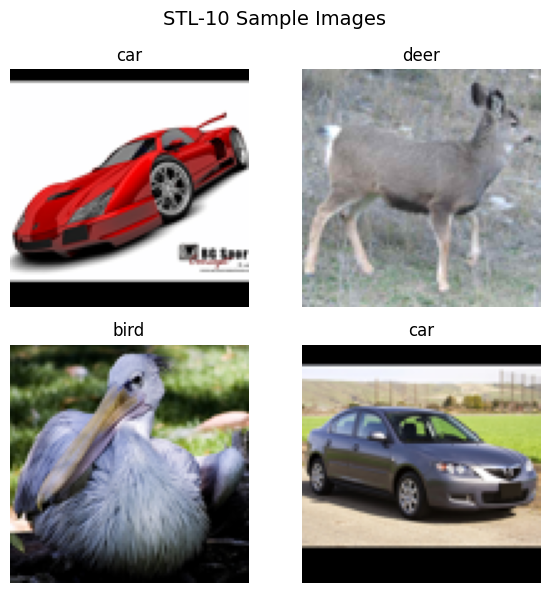

Supervised train samples : 5000
Unlabeled (SSL) samples  : 100000
Test samples             : 8000


In [13]:
# Class labels (unlabeled split has no classes)
classes = ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']

# Display 4 images in a 2x2 grid
def imshow(img):
    mean = np.array([0.4467, 0.4398, 0.4066])
    std  = np.array([0.2603, 0.2566, 0.2713])
    img = img.numpy().transpose((1, 2, 0))
    img = std * img + mean  # unnormalize
    return np.clip(img, 0, 1)

images, labels = next(iter(supervised_trainloader))
images = images[:4]
labels = labels[:4]

fig, axes = plt.subplots(2, 2, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(imshow(images[i]))
    ax.set_title(classes[labels[i]])
    ax.axis('off')

plt.suptitle('STL-10 Sample Images', fontsize=14)
plt.tight_layout()
plt.savefig('stl10_grid.png', dpi=150)
plt.show()

print(f"Supervised train samples : {len(supervised_trainset)}")
print(f"Unlabeled (SSL) samples  : {len(unlabeled_set)}")
print(f"Test samples             : {len(testset)}")

In [6]:
device = torch.device('cuda:0')

In [14]:
# IMage
D_image = 96
N_CHANNELS = 3

PATCH_SIZE = 8
D_patch = (PATCH_SIZE**2) * N_CHANNELS # 192
N_PATCHES = (D_image**2) / (PATCH_SIZE**2)

# Encoder
D = 192
N_HEADS = 3
Dk = D // N_HEADS # 64
D_mlp = 4*D

# Decoder
D_decoder = D # normally D//2 but ViT-Tiny with 1 Transformer block is already so shallow
D_decoder_mlp = 4*D_decoder

In [ ]:
# Calculate our 2D sine-cosine position embeddings


In [ ]:
class Net(nn.Module):

    def _init__(self):
        super(Net, self).__init__()

        ### ENCODER

        self.img2enc_projection = nn.Linear(D_patch, D)

        # Need to define sine/cosine position embeddings for each patch

        # Block 1
        self.norm1a = nn.LayerNorm(D)
        self.msa1 = nn.MultiheadAttention(D, N_HEADS)
        self.norm1b = nn.LayerNorm(D)
        self.mlp1a = nn.Linear(D, D_mlp)
        self.mlp1b = nn.Linear(D_mlp, D)

        # Block 2
        self.norm2a = nn.LayerNorm(D)
        self.msa2 = nn.MultiheadAttention(D, N_HEADS)
        self.norm2b = nn.LayerNorm(D)
        self.mlp2a = nn.Linear(D, D_mlp)
        self.mlp2b = nn.Linear(D_mlp, D)

        # Block 3
        self.norm3a = nn.LayerNorm(D)
        self.msa3 = nn.MultiheadAttention(D, N_HEADS)
        self.norm3b = nn.LayerNorm(D)
        self.mlp3a = nn.Linear(D, D_mlp)
        self.mlp3b = nn.Linear(D_mlp, D)

        ### DECODER (just single transformer block)
        self.enc2dec_projection = nn.Linear(D, D_decoder)
        self.decoder_norm1 = nn.LayerNorm(D_decoder)
        self.decoder_msa = nn.MultiheadAttention(D_decoder, N_HEADS)
        self.decoder_norm2 = nn.LayerNorm(D_decoder)
        self.decoder_mlp1 = nn.Linear(D_decoder, D_decoder_mlp)
        self.decoder_mlp2 = nn.Linear(D_decoder_mlp, D_decoder)
        self.dec2img_projection = nn.Linear(D_decoder, D_patch)

    def forward(x):
        pass
